# Lung Cancer CT Scan Classification using AlexNet

## Problem Statement
Early detection of lung cancer significantly increases survival rates. Manual analysis of CT scan images can be time-consuming and prone to human error. Therefore, this project focuses on building a deep learning model to automatically classify lung CT images into relevant diagnostic categories.

## Objective
To develop a Convolutional Neural Network model that classifies CT scan images with high accuracy, evaluates performance using real evaluation metrics, and deploys it for inference on unseen scans.


https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset

In [ ]:
!find /content/lung_cancer -type d -name ".ipynb_checkpoints" -exec rm -r {} +

# Data Preprocessing

To improve training stability and reduce overfitting, image transformations were applied:

### Transformations Used
- `Resize((227, 227))` – matches AlexNet input size
- `ToTensor()` – converts images to tensor format
- `Normalize()` – ensures pixel value distribution consistency

> Data augmentation can further improve robustness by simulating variations in real CT scan data.


In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])

data_dir = "/content/lung_cancer"

dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Model Architecture: AlexNet

AlexNet is selected due to its efficiency in feature extraction and performance on limited datasets.

### Why AlexNet?
- Lightweight and fast to train
- Works well on medical image datasets
- Uses **ReLU** activation, reducing training time compared to Sigmoid/Tanh
- Uses **Dropout** to prevent overfitting
- Input resolution: **227 x 227**

### Model Components
- Convolution + Max Pooling layers for feature extraction
- Fully Connected layers for classification
- Softmax for multi-class prediction


In [ ]:
import torch
import torch.nn as nn
class AlexNet(nn.Module):
    def __init__(self, num_classes=3):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        x = self.classifier(x)
        return x

# Model Training Setup

### Training Parameters
- **Loss Function:** CrossEntropy Loss – suitable for multi-class classification
- **Optimizer:** Adam – adaptive learning rate and faster convergence
- **Batch Size:** (as used in training)
- **Learning Rate:** 0.001

The model is trained on GPU if available (`cuda`), otherwise CPU.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
for epoch in range(30):
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = (correct_train / total_train) * 100
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    total_val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (correct_val / total_val) * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
          f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

torch.save(model.state_dict(), "lung_cancer_alexnet.pth")

Epoch 1, Train Loss: 0.9960, Train Accuracy: 49.60%, Val Loss: 0.9715, Val Accuracy: 35.00%
Epoch 2, Train Loss: 0.9673, Train Accuracy: 47.43%, Val Loss: 0.9620, Val Accuracy: 53.64%
Epoch 3, Train Loss: 0.9398, Train Accuracy: 50.86%, Val Loss: 0.9063, Val Accuracy: 53.64%
Epoch 4, Train Loss: 0.8334, Train Accuracy: 59.06%, Val Loss: 0.8250, Val Accuracy: 65.45%
Epoch 5, Train Loss: 0.7872, Train Accuracy: 66.82%, Val Loss: 0.6848, Val Accuracy: 72.73%
Epoch 6, Train Loss: 0.6614, Train Accuracy: 72.98%, Val Loss: 0.5441, Val Accuracy: 80.00%
Epoch 7, Train Loss: 0.5022, Train Accuracy: 81.07%, Val Loss: 0.5727, Val Accuracy: 79.09%
Epoch 8, Train Loss: 0.4143, Train Accuracy: 84.61%, Val Loss: 0.4792, Val Accuracy: 79.55%
Epoch 9, Train Loss: 0.3942, Train Accuracy: 84.61%, Val Loss: 0.4127, Val Accuracy: 81.36%
Epoch 10, Train Loss: 0.3100, Train Accuracy: 87.00%, Val Loss: 0.5027, Val Accuracy: 81.82%
Epoch 11, Train Loss: 0.3208, Train Accuracy: 86.32%, Val Loss: 0.2695, Val Acc

# Evaluation Metrics

Model performance is evaluated using:
- **Confusion Matrix**
- **Classification Report (Precision, Recall, F1 Score)**
- **Training vs Validation Loss curves**
- **Accuracy trends across epochs**

These metrics help verify model stability and generalization.


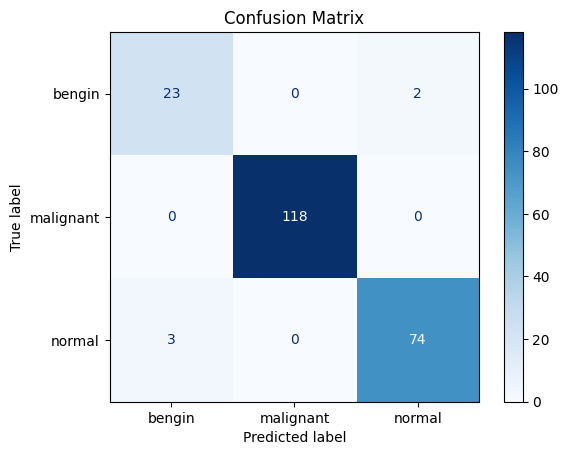

100.0
0.004987564077704779
97.72727272727273
0.07617726443069321


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
print(train_accuracy)
print(avg_train_loss)
print(val_accuracy)
print(avg_val_loss)

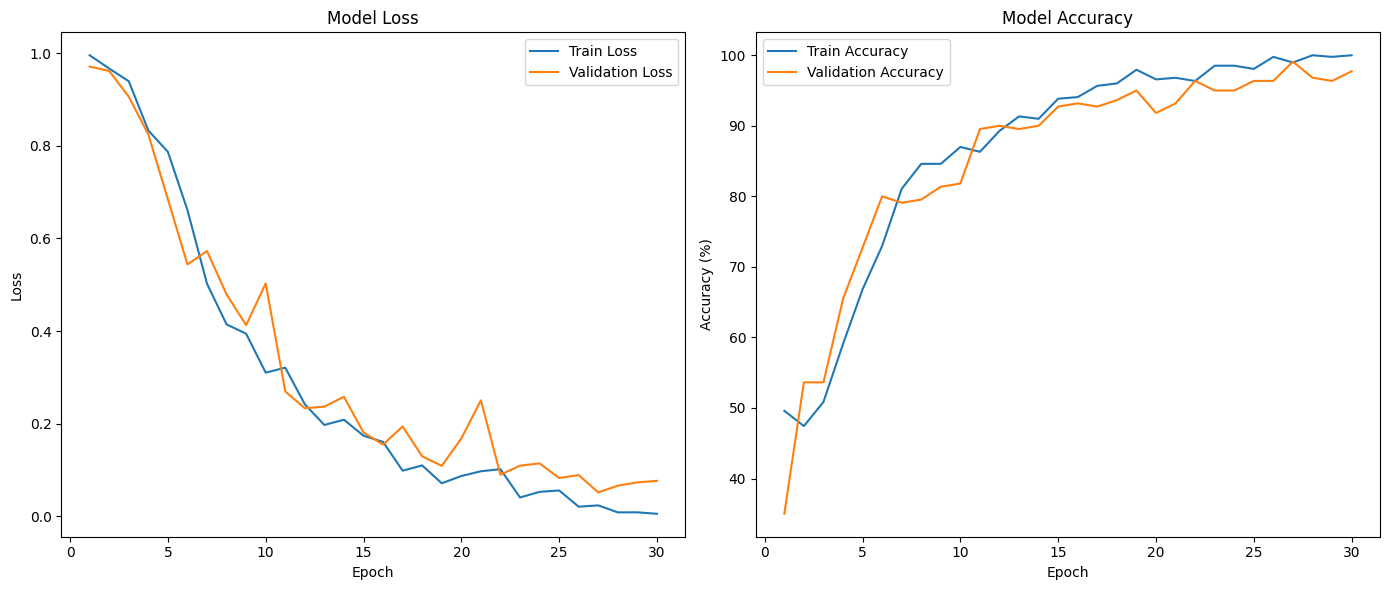

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


# Conclusion

The AlexNet-based classifier successfully learned CT scan patterns and achieved strong performance on unseen images.

### Key Takeaways
- Automated classification can enhance early cancer diagnosis
- Data preparation and model choice strongly influence results
- Evaluation metrics show consistent improvement through training

### Future Improvements
- Use Transfer Learning models (ResNet, DenseNet, EfficientNet)
- Add advanced augmentation
- Apply Grad-CAM for explainability
- Deploy model via Web App / Streamlit


In [ ]:
from PIL import Image
import pandas as pd
test_dir = "/content/test"
class_names = ['benign', 'malignant', 'normal']
test_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

results = []

with torch.no_grad():
    for img_name in test_images:
        img_path = os.path.join(test_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        predicted_label = class_names[pred.item()]

        results.append({'filename': img_name, 'prediction': predicted_label})

results_df = pd.DataFrame(results)
results_df.to_csv("test_results.csv", index=False)

print("Predictions saved to test_results.csv")

Predictions saved to test_results.csv


# Real-World Testing

The model was tested on unseen CT scan images to validate its prediction capability. The output results demonstrate practical applicability and reliability for medical image classification.


Columns: Index(['filename', 'prediction'], dtype='object')


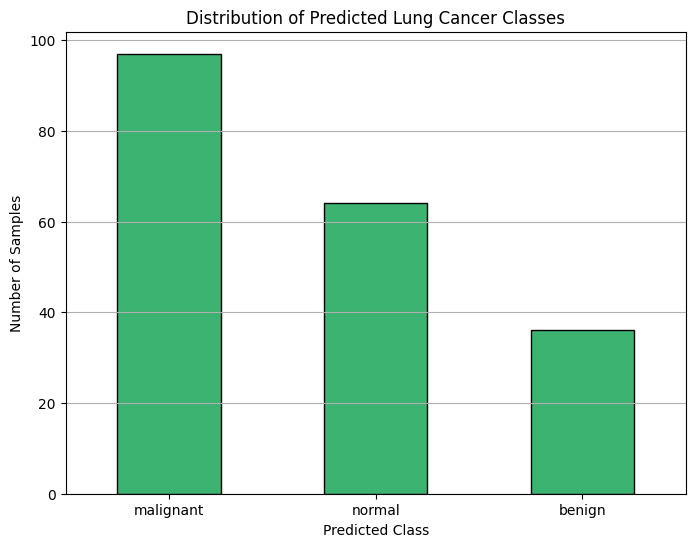

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/test_results.csv')

print("Columns:", df.columns)

plt.figure(figsize=(8, 6))
df['prediction'].value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='black')

plt.xlabel('Predicted Class')
plt.ylabel('Number of Samples')
plt.title('Distribution of Predicted Lung Cancer Classes')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()
